In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns
%matplotlib inline
sns.set(style="ticks")
from scipy.stats import zscore
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection   

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
r_df = pd.read_csv( 'Bank_Personal_Loan_Modelling.csv' )

In [6]:
#r_df.columns = ["ID","Age","Experience","Income","ZIPCode","Family","CCAvg","Education","Mortgage","PersonalLoan","SecuritiesAccount","CDAccount","Online","CreditCard"]

In [7]:
r_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,PersonalLoan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


Study the data distribution in each attribute, share your findings. (5 points)

In [8]:
r_df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'PersonalLoan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [9]:
r_df.shape

(5000, 14)

In [10]:
r_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
PersonalLoan          5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [11]:
# No columns have null data in the file
r_df.apply(lambda x : sum(x.isnull()))

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
PersonalLoan          0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [12]:
# Eye balling the data
r_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
PersonalLoan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [13]:
#finding unique data
r_df.apply(lambda x: len(x.unique()))

ID                    5000
Age                     45
Experience              47
Income                 162
ZIP Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
PersonalLoan             2
Securities Account       2
CD Account               2
Online                   2
CreditCard               2
dtype: int64

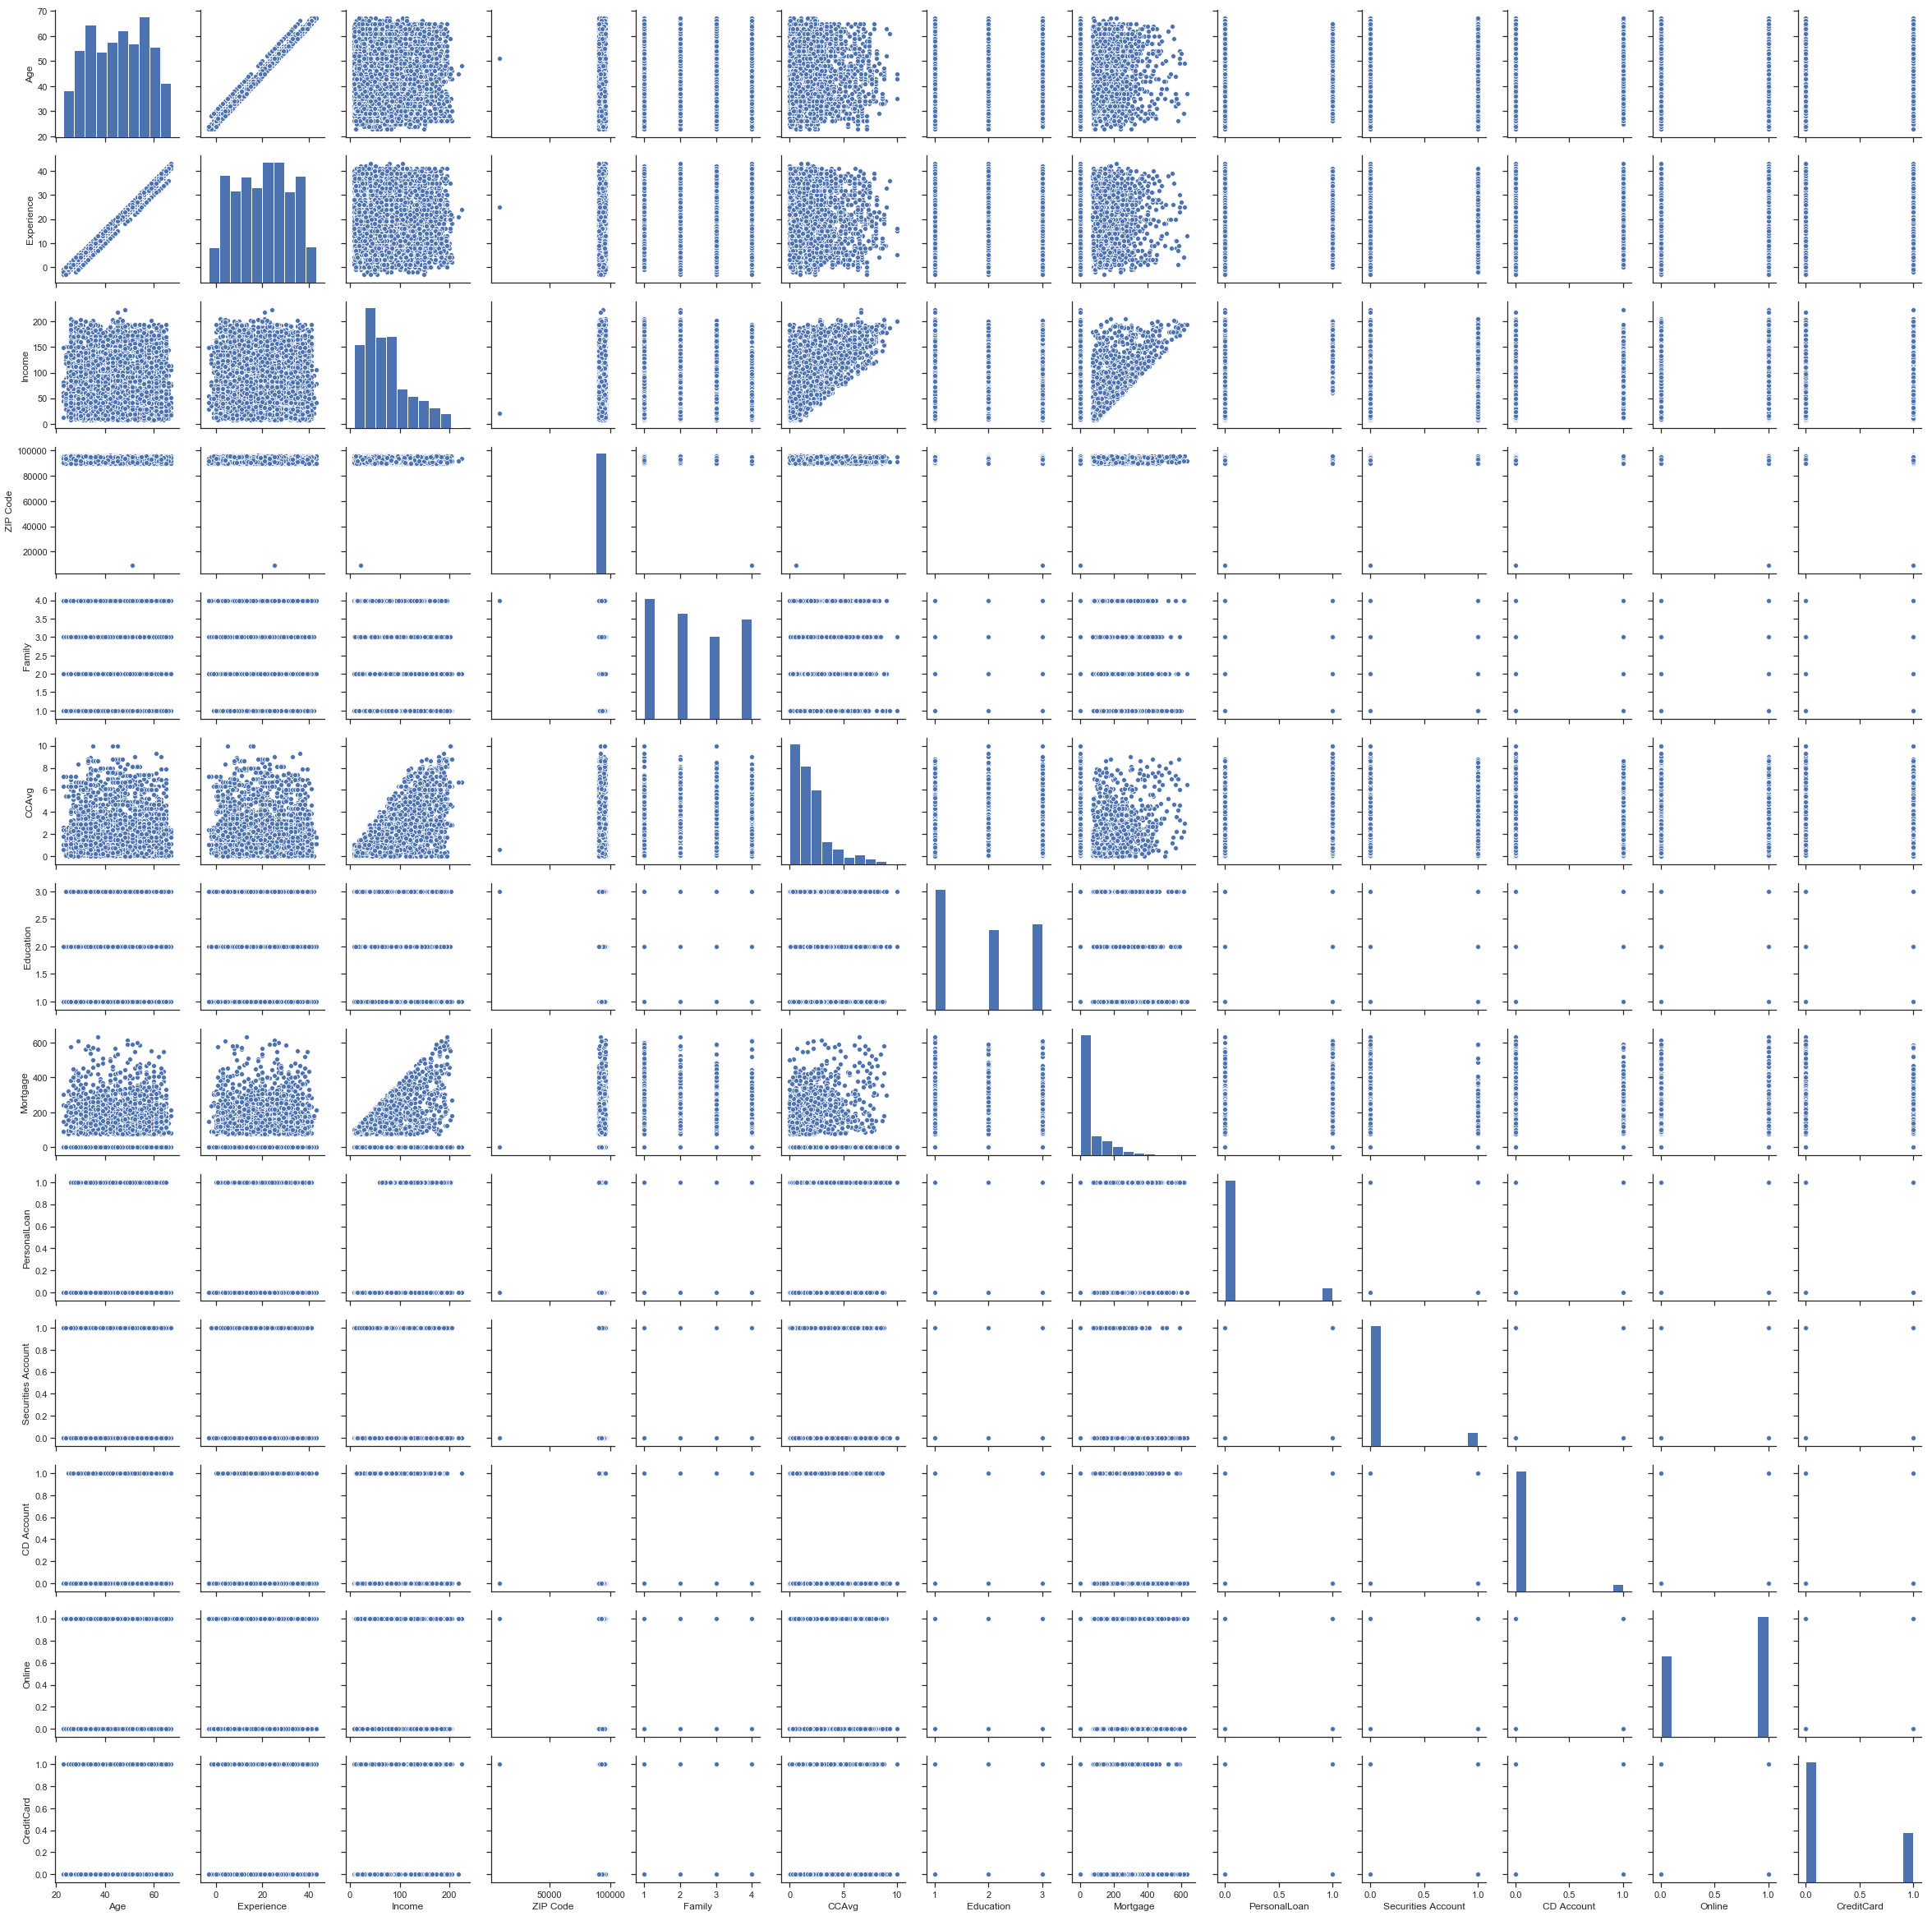

In [14]:
sns.pairplot(r_df.iloc[:,1:])

-Age feature is normally distributed with majority of customers falling between 30 years and 60 years of age. We can confirm this by looking at the describe statement above, which shows mean is almost equal to median
-Experience is normally distributed with more customer having experience starting from 8 years. Here the mean is equal to median. There are negative values in the Experience. This could be a data input error as in general it is not possible to measure negative years of experience. We can delete these values, because we have 3 or 4 records from the sample.
-Income is positively skewed. Majority of the customers have income between 45K and 55K. We can confirm this by saying the mean is greater than the median
-CCAvg is also a positively skewed variable and average spending is between 0K to 10K and majority spends less than 2.5K
Mortgage 70% of the individuals have a mortgage of less than 40K. However the max value is 635K
-The variables family and education are ordinal variables. The distribution of families is evenly distributes

In [15]:
# there are 52 records with negative experience. Before proceeding any further we need to clean the same
r_df[r_df['Experience'] < 0]['Experience'].count()

52

In [16]:
#clean the negative variable
dfExp = r_df.loc[r_df['Experience'] >0]
negExp = r_df.Experience < 0
column_name = 'Experience'
mylist = r_df.loc[negExp]['ID'].tolist() # getting the customer ID who has negative experience

In [17]:
# there are 52 records with negative experience
negExp.value_counts()

False    4948
True       52
Name: Experience, dtype: int64

The following code does the below steps:

For the record with the ID, get the value of Age column
For the record with the ID, get the value of Education column
Filter the records matching the above criteria from the data frame which has records with positive experience and take the median
Apply the median back to the location which had negative experience

In [18]:
for id in mylist:
    age = r_df.loc[np.where(r_df['ID']==id)]["Age"].tolist()[0]
    education = r_df.loc[np.where(r_df['ID']==id)]["Education"].tolist()[0]
    df_filtered = dfExp[(dfExp.Age == age) & (dfExp.Education == education)]
    exp = df_filtered['Experience'].median()
    r_df.loc[r_df.loc[np.where(r_df['ID']==id)].index, 'Experience'] = exp

In [19]:
# checking if there are records with negative experience
r_df[r_df['Experience'] < 0]['Experience'].count()

0

Get the target column distribution. Your comments (5 points)

In [20]:
r_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,4971.0,20.243211,11.359189,0.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
PersonalLoan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


Influence of income and education on personal loan

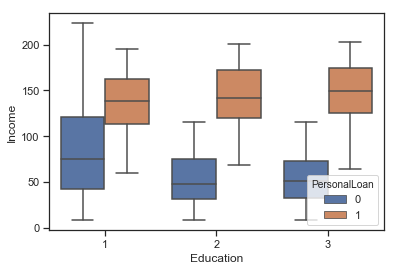

In [21]:
sns.boxplot(x='Education',y='Income',hue='PersonalLoan',data=r_df)

the customers whose education level is 1 is having more income. However customers who has taken the personal loan have the same income levels

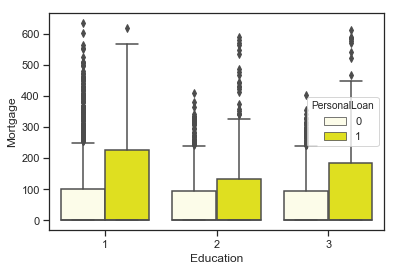

In [22]:
sns.boxplot(x="Education", y='Mortgage', hue="PersonalLoan", data=r_df,color='yellow')

 From the above chart it seems that customer who do not have personal loan and customer who has personal loan have high mortgage

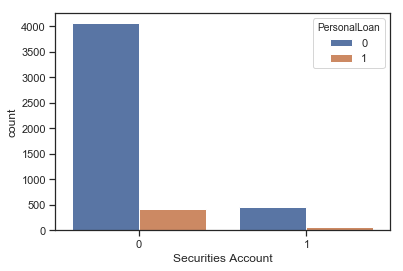

In [23]:
sns.countplot(x="Securities Account", data=r_df,hue="PersonalLoan")

Majority of customers who does not have loan have securities account

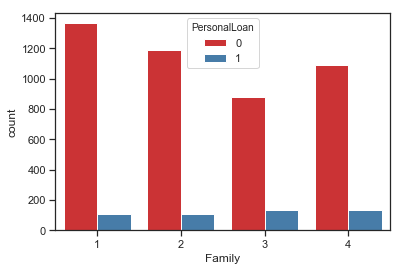

In [24]:
sns.countplot(x='Family',data=r_df,hue='PersonalLoan',palette='Set1')

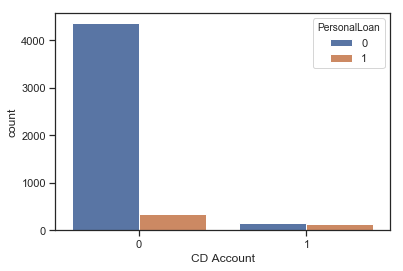

In [25]:
sns.countplot(x='CD Account',data=r_df,hue='PersonalLoan')

Customers who does not have CD account , does not have loan as well. This seems to be majority. But almost all customers who has CD account has loan as well

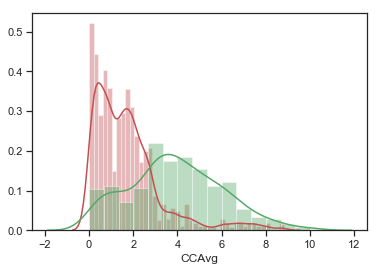

In [26]:
sns.distplot (r_df [r_df.PersonalLoan == 0]['CCAvg'], color = 'r')
sns.distplot (r_df [r_df.PersonalLoan == 1]['CCAvg'], color = 'g')

In [27]:
print('Credit card spending of Non-Loan customers: ',r_df [r_df.PersonalLoan == 0]['CCAvg'].median()*1000)
print('Credit card spending of Loan customers    : ', r_df [r_df.PersonalLoan == 1]['CCAvg'].median()*1000)

Credit card spending of Non-Loan customers:  1400.0
Credit card spending of Loan customers    :  3800.0


The graph show persons who have personal loan have a higher credit card average. Average credit card spending with a median of 3800 dollar indicates a higher probability of personal loan. Lower credit card spending with a median of 1400 dollars is less likely to take a loan. This could be useful information.

Text(0, 0.5, 'Age')

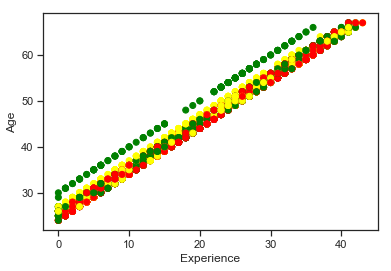

In [28]:
fig, ax = plot.subplots()
colors = {1:'red',2:'yellow',3:'green'}
ax.scatter(r_df['Experience'],r_df['Age'],c=r_df['Education'].apply(lambda x:colors[x]))
plot.xlabel('Experience')
plot.ylabel('Age')

 The above plot show with experience and age have a positive correlation. As experience increase age also increases. Also the colors show the education level. There is gap in the mid forties of age and also more people in the under graduate level

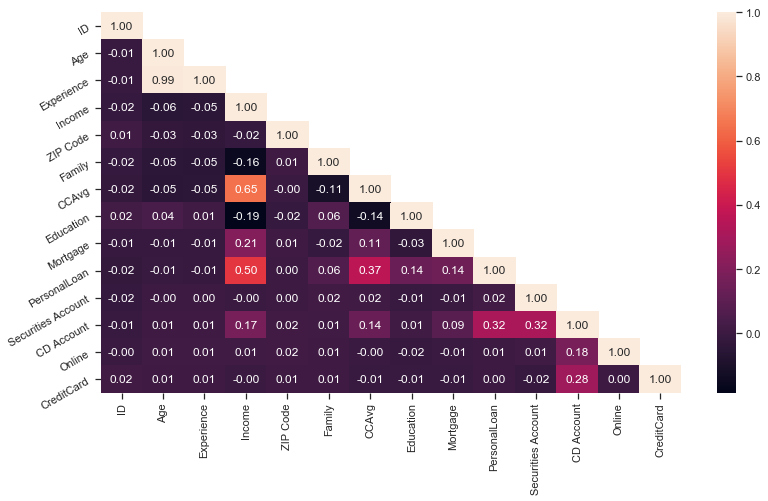

In [29]:
# Correlation with heat map
import matplotlib.pyplot as plt
import seaborn as sns
corr = r_df.corr()
sns.set_context("notebook", font_scale=1.0, rc={"lines.linewidth": 2.5})
plt.figure(figsize=(13,7))
# create a mask so we only see the correlation values once
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, 1)] = True
a = sns.heatmap(corr,mask=mask, annot=True, fmt='.2f')
rotx = a.set_xticklabels(a.get_xticklabels(), rotation=90)
roty = a.set_yticklabels(a.get_yticklabels(), rotation=30)

Income and CCAvg is moderately correlated.
Age and Experience is highly correlated

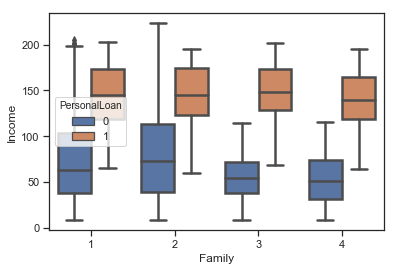

In [30]:
sns.boxplot(x=r_df.Family,y=r_df.Income,hue=r_df.PersonalLoan)
# Looking at the below plot, families with income less than 100K are less likely to take loan,than families with 
# high income

Applying models

Split data into train and test

Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

In [31]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(r_df.drop(['ID','Experience'], axis=1), test_size=0.3 , random_state=100)

In [32]:
train_labels = train_set.pop('PersonalLoan')
test_labels = test_set.pop('PersonalLoan')

Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)


Decision tree classifier

In [55]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

#dt_model=DecisionTreeClassifier(criterion = 'entropy',max_depth=3)
#dt_model.fit(train_set, train_labels)

In [53]:
#.score(test_set , test_labels)

In [54]:
#y_predict = dt_model.predict(test_set)
y_predict[:5]

array([0, 0, 0, 0, 0], dtype=int64)

In [52]:
#test_set.head(5)

Naive Bayes

In [37]:
naive_model = GaussianNB()
naive_model.fit(train_set, train_labels)

prediction = naive_model.predict(test_set)
naive_model.score(test_set,test_labels)

0.8866666666666667

Random Forest classifier

In [38]:
randomforest_model = RandomForestClassifier(max_depth=2, random_state=0)
randomforest_model.fit(train_set, train_labels)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=2, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

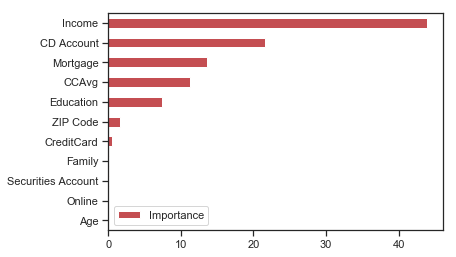

In [39]:
Importance = pd.DataFrame({'Importance':randomforest_model.feature_importances_*100}, index=train_set.columns)
Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='r', )

In [40]:
predicted_random=randomforest_model.predict(test_set)
randomforest_model.score(test_set,test_labels)

0.8993333333333333

KNN ( K - Nearest Neighbour )

In [41]:
train_set_indep = r_df.drop(['Experience' ,'ID'] , axis = 1).drop(labels= "PersonalLoan" , axis = 1)
train_set_dep = r_df["PersonalLoan"]
X = np.array(train_set_indep)
Y = np.array(train_set_dep)
X_Train = X[ :3500, :]
X_Test = X[3501: , :]
Y_Train = Y[:3500, ]
Y_Test = Y[3501:, ]

In [42]:
knn = KNeighborsClassifier(n_neighbors= 21 , weights = 'uniform', metric='euclidean')
knn.fit(X_Train, Y_Train)    
predicted = knn.predict(X_Test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(Y_Test, predicted)
print(acc)

0.9106070713809206


Model comparison

In [43]:
X=r_df.drop(['PersonalLoan','Experience','ID'],axis=1)
y=r_df.pop('PersonalLoan')

Print the confusion matrix for all the above models (10 points)

In [44]:
def modelPerformanceAnalysis (X, y, model, test_size = 0.3, seed = 7):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    model.fit(X_train, y_train)
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > 0.5, 1, 0)
    fpr, tpr, thresholds = roc_curve(y_train, model.predict_proba(X_train)[:,1])
    roc_auc = auc(fpr, tpr)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], 0.5, trainAccuracy, trainRecall, trainPrecision, trainF1score, roc_auc]
    # Test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], 0.5, testAccuracy, testRecall, testPrecision, testF1score, roc_auc]
    
    #### Optimize probability threshold and calculate performance numbers
    y_predictProb = model.predict_proba(X_train)
    fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
    optimalF1 = 0
    optimalTh = 0
    for th in thresholds:
        preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
        f1Score = f1_score(y_train, preds)
        if(optimalF1 < f1Score):
            optimalF1 = f1Score
            optimalTh = th

    resultsDf = pd.DataFrame( index=["dataSize", "optimalTh", "accuracy", "recall", "precision", "f1_score", "auc"])
    # Optimal probability threshold based train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > optimalTh, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    optimalTrainResults=[X_train.shape[0], optimalTh, trainAccuracy, trainRecall, trainPrecision, trainF1score, roc_auc]
    # Optimal probability threshold based test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    optimalTestResults=[X_test.shape[0], optimalTh, testAccuracy, testRecall, testPrecision, testF1score, roc_auc]
    # Concatenate Train and Test results to resultsDf
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    resultsDf['optimalTrainResults'] = optimalTrainResults
    resultsDf['optimalTestResults'] = optimalTestResults
    
    return resultsDf.round(2)

In [45]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.metrics import roc_curve, auc
knn = KNeighborsClassifier(n_neighbors=5)
#dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2)

In [46]:
modelPerformanceAnalysis(X, y, knn, 0.3, 7)

,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3500.00,1500.00,3500.00,1500.00
optimalTh,0.50,0.50,0.20,0.20
accuracy,0.92,0.91,0.92,0.89
recall,0.40,0.24,0.75,0.43
precision,0.69,0.54,0.56,0.42
f1_score,0.51,0.33,0.64,0.43
auc,0.95,0.95,0.95,0.95


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
lrModel = LogisticRegression()
nbModel = GaussianNB()

In [48]:
modelPerformanceAnalysis (X, y, nbModel, test_size = 0.3, seed = 7)

,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3500.00,1500.00,3500.00,1500.00
optimalTh,0.50,0.50,0.06,0.06
accuracy,0.89,0.88,0.87,0.86
recall,0.56,0.59,0.81,0.85
precision,0.43,0.40,0.41,0.39
f1_score,0.49,0.48,0.54,0.53
auc,0.93,0.93,0.93,0.93


In [49]:
modelPerformanceAnalysis (X, y, lrModel, test_size = 0.3, seed = 7)

,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3500.00,1500.00,3500.00,1500.00
optimalTh,0.50,0.50,0.19,0.19
accuracy,0.91,0.92,0.88,0.90
recall,0.31,0.30,0.69,0.75
precision,0.53,0.59,0.44,0.47
f1_score,0.39,0.40,0.54,0.58
auc,0.92,0.92,0.92,0.92


Give your reasoning on which is the best model in this case and why it performs better? (10 points)

Recall score anaysis : NB has the best value of recall @ 0.81 as against the LR (0.67) & KNN (0.75)
Precision score analysis : KNN has the best value of precision @ 0.56 as against the LR (0.44) & NB (0.41)
F1 score analysis : KNN has better F1 score @ 0.64 as agaist LR & NB (0.54). 
KNN's AUC @ 0.95 betters the one compared with 0.92 (LR) & 0.93 (NB)
The Accuracy score for KNN (0.92) betters the LR (0.88) and NB (0.87)

Hence the KNN model is recommended. KNN model will fit to the business requirement and add value

In [50]:
modelPerformanceAnalysis (X, y, rf, test_size = 0.3, seed = 7)

,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3500.00,1500.00,3500.00,1500.00
optimalTh,0.50,0.50,0.37,0.37
accuracy,0.98,0.98,0.99,0.99
recall,0.81,0.85,0.92,0.91
precision,0.99,0.98,0.98,0.95
f1_score,0.89,0.91,0.95,0.93
auc,1.00,1.00,1.00,1.00


Proceeding further and analysing as above we can see that Random forest gives a better result than KNN. Just for information and moving further than the scope of this question